# **HR Attrition Prediction (Classification**)

# **Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,productivity loss, and reduced employee morale.

The goal is to build a Machine Learning classification model that predicts whether an employee will leave the company(Attrition: Yes/No)

### **Import Libraries**

In [690]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

##**Load Data**

In [691]:
data=pd.read_csv('HR-Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# **Understanding Variables that are needed for classification**
**Age**: The age of the employee.

**Attrition**: The attrition status of the employee (binary: yes/no).

**BusinessTravel**: Frequency of business travel (e.g., non-travel, travel frequently, etc.).

**DistanceFromHome**: The distance from the employee's home to the workplace.

**EnvironmentSatisfaction**: The level of satisfaction with the work environment.

**Gender**: The gender of the employee.

**JobRole**: The role or position of the employee.

**JobSatisfaction**: The level of job satisfaction reported by the employee.

**MaritalStatus**: The marital status of the employee.

**MonthlyIncome**: The monthly income of the employee.

**OverTime**: Indicates if the employee works overtime (binary: yes/no).

**PercentSalaryHike**: The percentage increase in salary for the employee.

**PerformanceRating**: The performance rating of the employee.

**RelationshipSatisfaction**: The level of satisfaction with relationships at work.

**StockOptionLevel**: The level of stock options awarded to the employee.

**TotalWorkingYears**: The total number of years the employee has worked.

**YearsAtCompany**: The number of years the employee has worked at the current company.

**YearsWithCurrManager**: The number of years the employee has been with the current manager.


# **Basic Checks**

In [692]:
data.shape

(1470, 35)

In [693]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [694]:
data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [695]:
data.info()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [696]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [697]:
print(data.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [698]:
num_col= data.select_dtypes(include=['int64','float64'])
num_col

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [699]:
cat_cols = data.select_dtypes(include=['object'])
cat_cols

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [700]:
for x in cat_cols:
  print(x,'--->',data[x].unique())

Attrition ---> ['Yes' 'No']
BusinessTravel ---> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department ---> ['Sales' 'Research & Development' 'Human Resources']
EducationField ---> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender ---> ['Female' 'Male']
JobRole ---> ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus ---> ['Single' 'Married' 'Divorced']
Over18 ---> ['Y']
OverTime ---> ['Yes' 'No']


In [701]:
for x in cat_cols:
  print(data[x].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
Over18
Y    1470
Name: count,

In [702]:
print(data.nunique())

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

# **Data Cleaning**

### **Check for Missng values**

In [703]:
data.isnull().sum().sum()

np.int64(0)

### **Check for duplicates**

In [704]:
data.duplicated().sum()

np.int64(0)

In [705]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [706]:
cols_to_drop = ['EmployeeNumber','Over18','StandardHours', 'EmployeeCount']

data.drop(columns=cols_to_drop,inplace=True)

In [707]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [708]:
num_cols= data.select_dtypes(include=['int64','float64'])
num_cols

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,2,94,3,2,4,5993,...,3,1,0,8,0,1,6,4,0,5
1,49,279,8,1,3,61,2,2,2,5130,...,4,4,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,92,2,1,3,2090,...,3,2,0,7,3,3,0,0,0,0
3,33,1392,3,4,4,56,3,1,3,2909,...,3,3,0,8,3,3,8,7,3,0
4,27,591,2,1,1,40,3,1,2,3468,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,3,3,1,17,3,3,5,2,0,3
1466,39,613,6,1,4,42,2,3,1,9991,...,3,1,1,9,5,3,7,7,1,7
1467,27,155,4,3,2,87,4,2,2,6142,...,4,2,1,6,0,3,6,2,0,3
1468,49,1023,2,3,4,63,2,2,2,5390,...,3,4,0,17,3,2,9,6,0,8


#  **Exploratory data analysis**

## **Univariate**

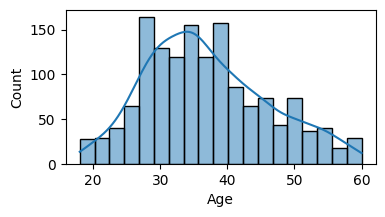

In [709]:
plt.figure(figsize=(4,2))
sns.histplot(data,x='Age',kde=True)
plt.show()

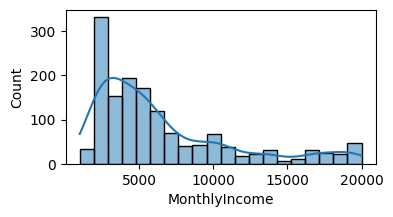

In [710]:
plt.figure(figsize=(4,2))
sns.histplot(data,x='MonthlyIncome',kde=True)
plt.show()

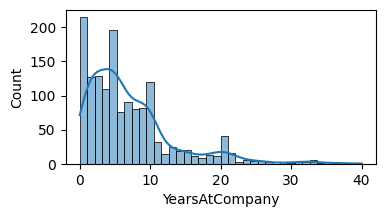

In [711]:
plt.figure(figsize=(4,2))
sns.histplot(data,x='YearsAtCompany',kde=True)
plt.show()

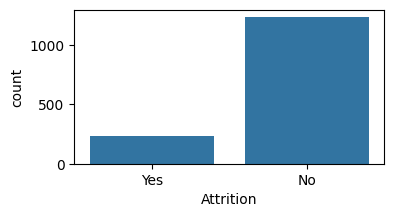

In [712]:
plt.figure(figsize=(4,2))
sns.countplot(data,x='Attrition')
plt.show()

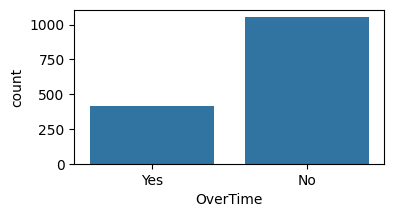

In [713]:
plt.figure(figsize=(4,2))
sns.countplot(data,x='OverTime')
plt.show()

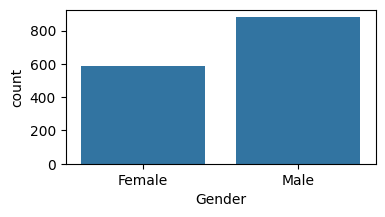

In [714]:
plt.figure(figsize=(4,2))
sns.countplot(data,x='Gender')
plt.show()

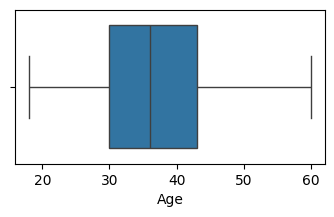

In [715]:
plt.figure(figsize=(4,2))
sns.boxplot(data,x='Age')
plt.show()

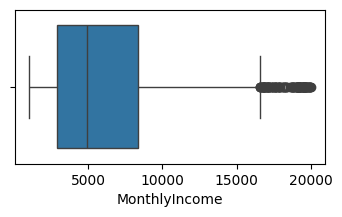

In [716]:
plt.figure(figsize=(4,2))
sns.boxplot(data,x='MonthlyIncome')
plt.show()

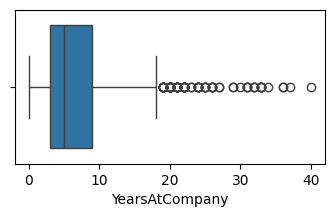

In [717]:
plt.figure(figsize=(4,2))
sns.boxplot(data,x='YearsAtCompany')
plt.show()

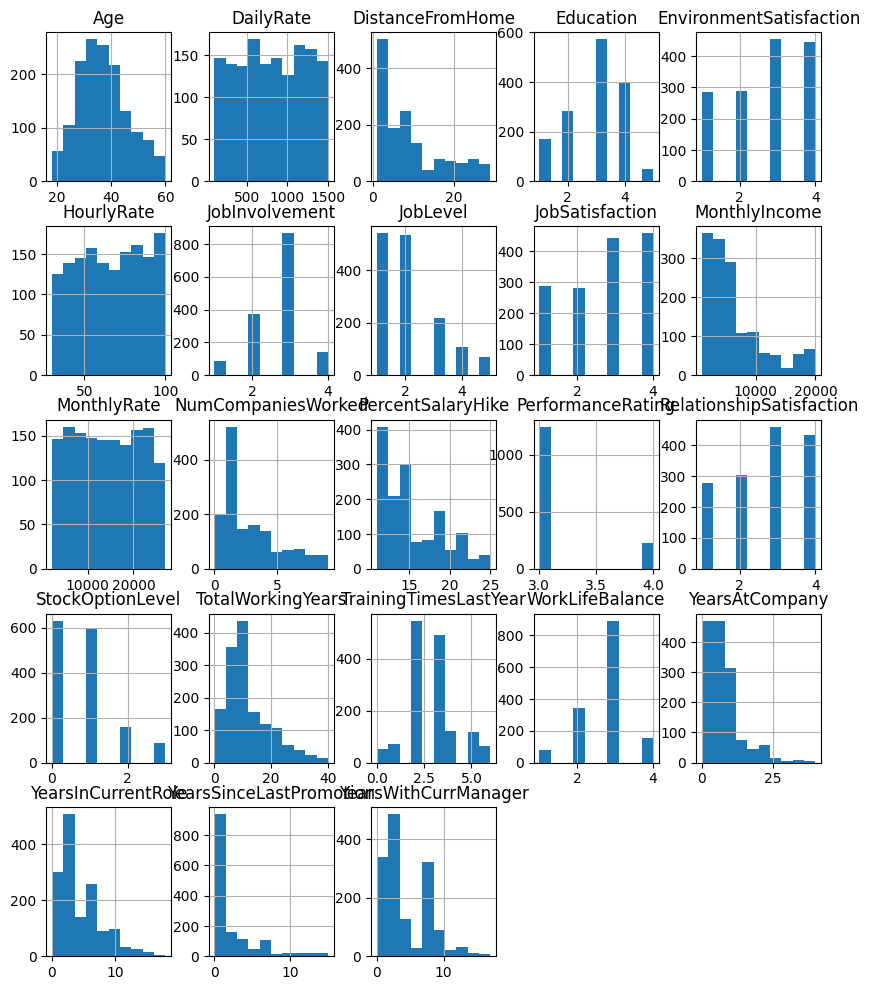

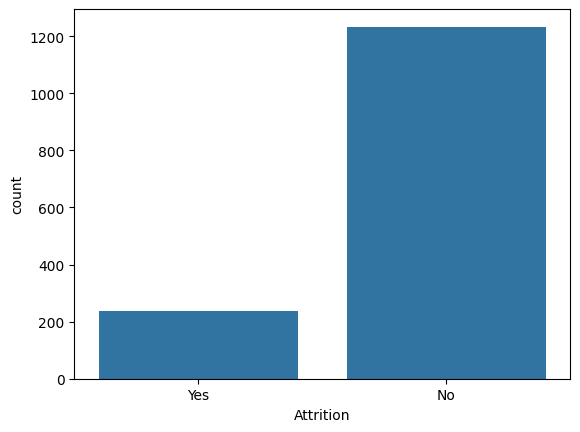

In [718]:
data.hist(figsize=(10,12))
plt.show()
sns.countplot(data,x='Attrition')
plt.show()

###**Bivariate Analysis**

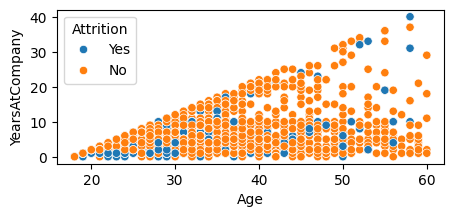

In [719]:
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='YearsAtCompany',hue='Attrition')
plt.show()

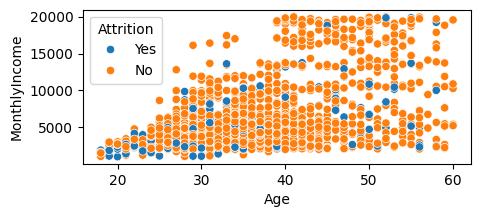

In [720]:
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='MonthlyIncome',hue='Attrition')
plt.show()

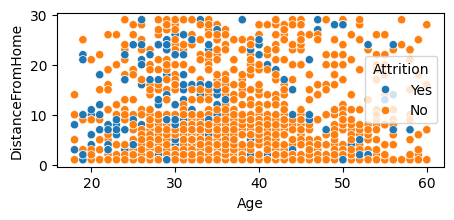

In [721]:
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='DistanceFromHome',hue='Attrition')
plt.show()

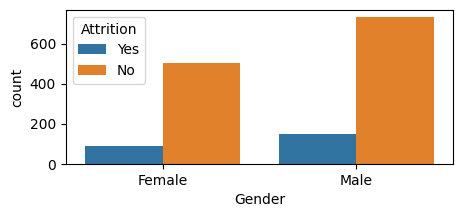

In [722]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender',hue='Attrition')
plt.show()

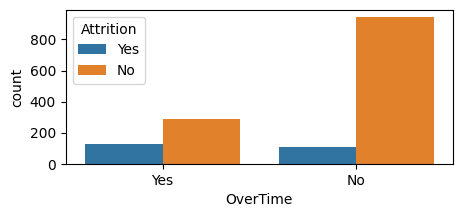

In [723]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='OverTime',hue='Attrition')
plt.show()

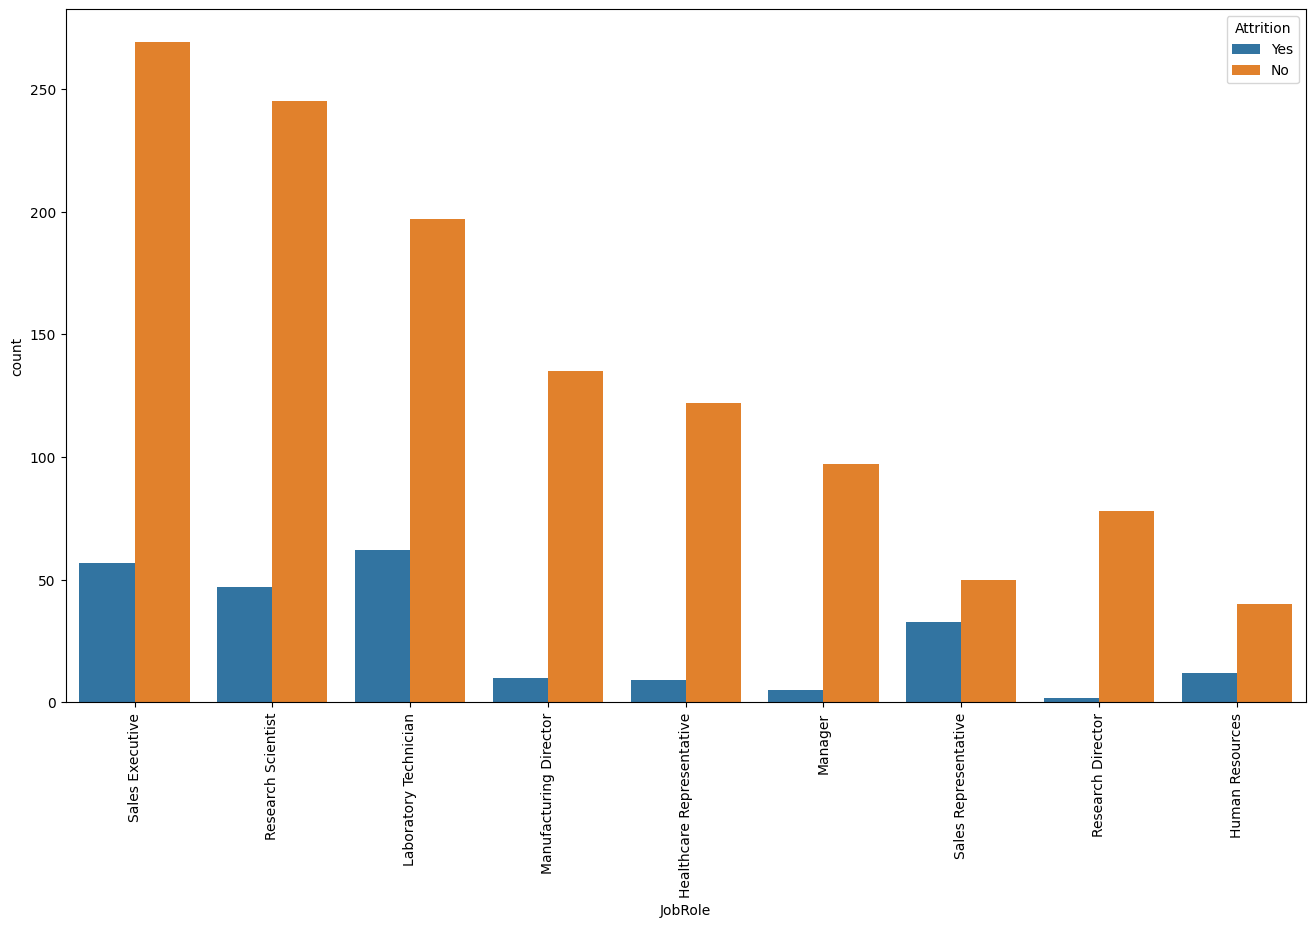

In [724]:
plt.figure(figsize=(16,9))
sns.countplot(data,x='JobRole',hue='Attrition')
plt.xticks(rotation=90)
plt.show()

**Pairplot**

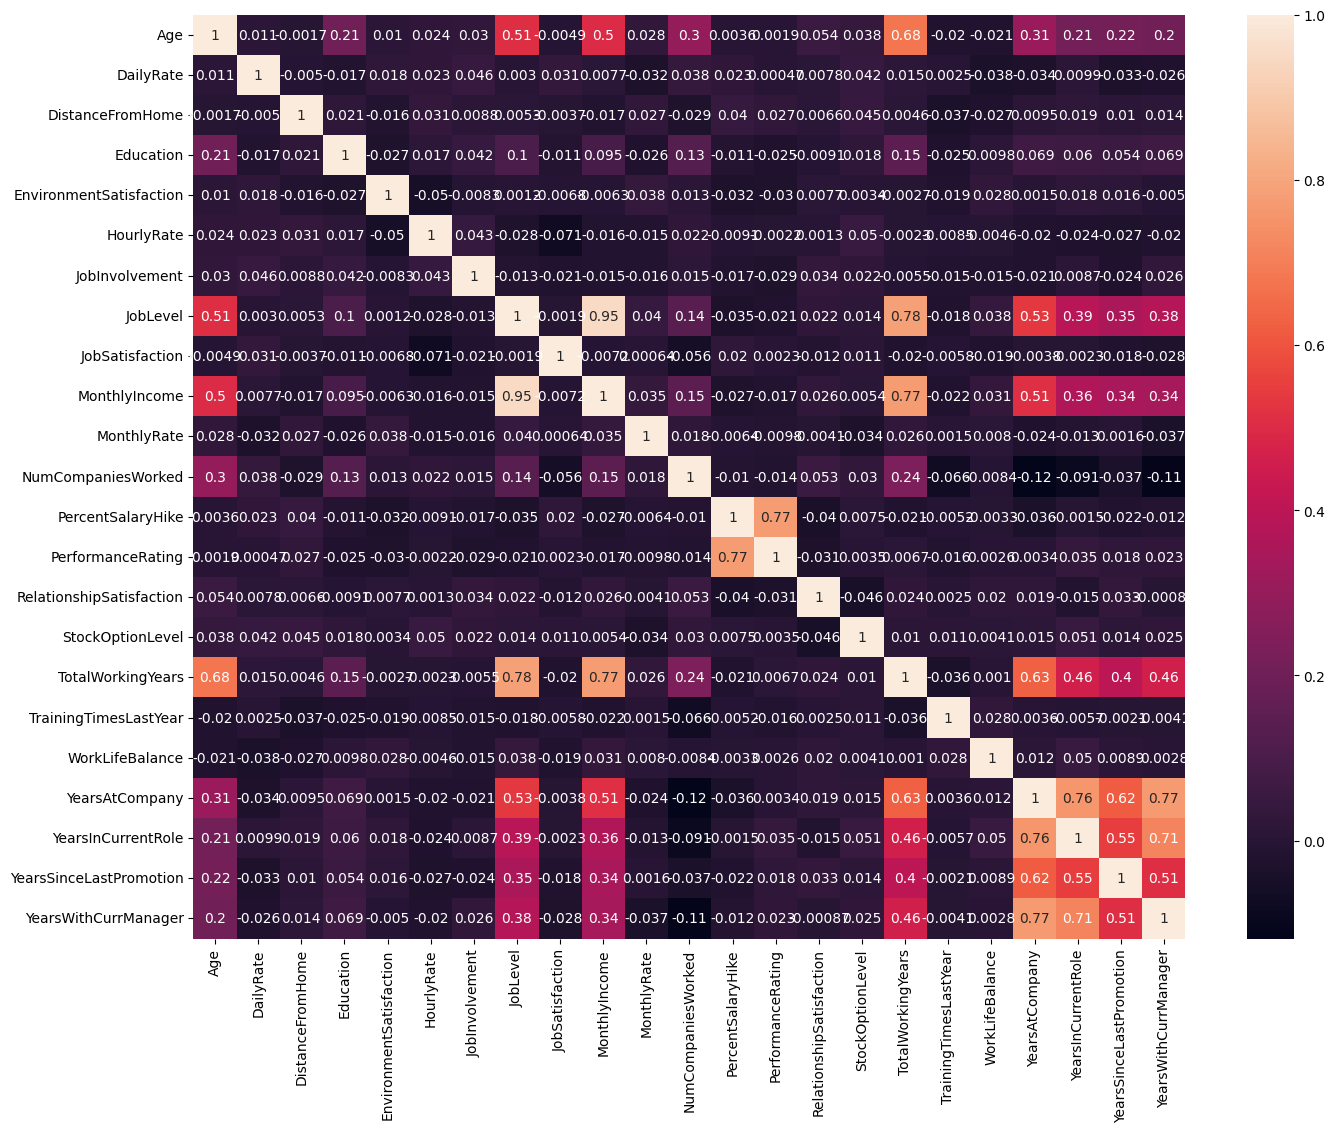

In [725]:
plt.figure(figsize=(16,12))
sns.heatmap(num_cols.corr(),annot=True)
plt.show()

In [726]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

# **Handling Outliers**

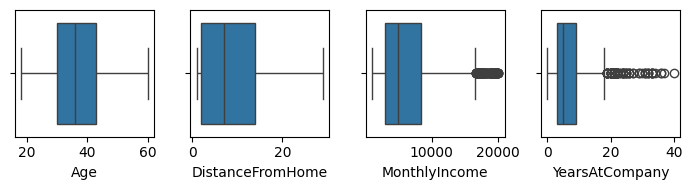

In [727]:
fig,ax=plt.subplots(1,4,figsize=(7,2))
sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='DistanceFromHome',ax=ax[1])
sns.boxplot(data,x='MonthlyIncome',ax=ax[2])
sns.boxplot(data,x='YearsAtCompany',ax=ax[3])
plt.tight_layout()

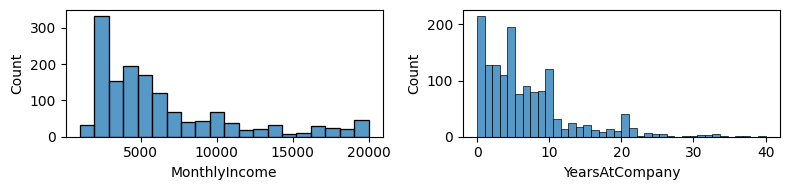

In [728]:
fig,ax=plt.subplots(1,2,figsize=(8,2))
sns.histplot(data,x='MonthlyIncome',ax=ax[0])
sns.histplot(data,x='YearsAtCompany',ax=ax[1])
plt.tight_layout()

In [729]:
data.loc[:,'MonthlyIncome'].skew()

np.float64(1.3698166808390662)

In [730]:
data.loc[:,'YearsAtCompany'].skew()

np.float64(1.7645294543422085)

In [731]:
Q1 = data.loc[:,'MonthlyIncome'].quantile(0.25)
Q3 = data.loc[:,'MonthlyIncome'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [732]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'MonthlyIncome']>upper_limit)|(data.loc[:,'MonthlyIncome']<lower_limit)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53,No,Travel_Rarely,1282,Research & Development,5,3,Other,3,Female,...,3,4,1,26,3,2,14,13,4,8
29,46,No,Travel_Rarely,705,Sales,2,4,Marketing,2,Female,...,3,4,0,22,2,2,2,2,2,1
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,...,3,4,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,2,Female,...,3,4,1,29,2,2,27,3,13,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,3,Female,...,4,4,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,4,Female,...,3,3,1,29,2,2,1,0,0,0
1377,49,No,Travel_Frequently,1064,Research & Development,2,1,Life Sciences,2,Male,...,3,4,0,28,3,3,5,4,4,3
1401,55,No,Travel_Rarely,189,Human Resources,26,4,Human Resources,3,Male,...,3,1,1,35,0,3,10,9,1,4
1437,39,No,Non-Travel,105,Research & Development,9,3,Life Sciences,4,Male,...,3,3,0,21,3,2,6,0,1,3


In [733]:
len(data[(data.loc[:,'MonthlyIncome']>upper_limit)|(data.loc[:,'MonthlyIncome']<lower_limit)])/len(data)*100

7.755102040816326

Since % of outliers is more than 5% will leave them as it is.

In [734]:
Q1 = data.loc[:,'YearsAtCompany'].quantile(0.25)
Q3 = data.loc[:,'YearsAtCompany'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [735]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,Female,...,3,3,0,31,3,3,25,8,3,7
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,Female,...,3,4,1,24,4,3,22,6,5,17
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,...,3,4,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,2,Female,...,3,4,1,29,2,2,27,3,13,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,Female,...,3,4,0,28,3,2,21,16,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,39,No,Travel_Rarely,119,Sales,15,4,Marketing,2,Male,...,3,1,0,21,3,3,20,8,11,10
1404,42,No,Non-Travel,335,Research & Development,23,2,Life Sciences,4,Male,...,3,4,0,20,2,3,20,9,3,7
1443,42,No,Travel_Rarely,300,Research & Development,2,3,Life Sciences,1,Male,...,3,1,0,24,2,2,22,6,4,14
1445,41,No,Travel_Rarely,582,Research & Development,28,4,Life Sciences,1,Female,...,4,3,1,21,3,3,20,7,0,10


In [736]:
len(data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)])/len(data)*100

7.07482993197279

Since % of outliers is more than 5% will leave them as it is.

# **Encoding**

In [737]:
from sklearn.preprocessing import LabelEncoder
scaler = LabelEncoder()
data.loc[:,'attrition']=scaler.fit_transform(data.loc[:,'Attrition'])
data.loc[:,'overtime']=scaler.fit_transform(data.loc[:,'OverTime'])


In [738]:
data = pd.get_dummies(data,columns=['Gender'],dtype='int')

In [739]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,overtime,Gender_Female,Gender_Male
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,94,...,0,1,6,4,0,5,1,1,1,0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,61,...,3,3,10,7,1,7,0,0,0,1
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,92,...,3,3,0,0,0,0,1,1,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,56,...,3,3,8,7,3,0,0,1,1,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,40,...,3,3,2,2,2,2,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,41,...,3,3,5,2,0,3,0,0,0,1
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,42,...,5,3,7,7,1,7,0,0,0,1
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,87,...,0,3,6,2,0,3,0,1,0,1
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,63,...,3,2,9,6,0,8,0,0,0,1


In [740]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'attrition', 'overtime', 'Gender_Female',
       'Gender_Male'],
      dtype='object')

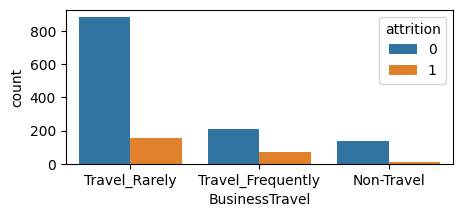

In [741]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='BusinessTravel',hue='attrition')
plt.show()

In [742]:
# use map
data.loc[:,'BusinessTravel']=data.loc[:,'BusinessTravel'].map({'Travel_Rarely':2,'Travel_Frequently':1,'Non-Travel':0})

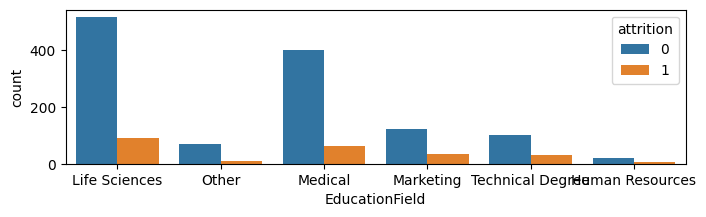

In [743]:
plt.figure(figsize=(8,2))
sns.countplot(data,x='EducationField',hue='attrition')
plt.show()

In [744]:
# use map
data.loc[:,'EducationField']=data.loc[:,'EducationField'].map({'Life Sciences':5,'Medical':4,'Marketing':3,'Technical Degree':2,'Other':1,'Human Resources':0})

In [745]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,overtime,Gender_Female,Gender_Male
0,41,Yes,2,1102,Sales,1,2,5,2,94,...,0,1,6,4,0,5,1,1,1,0
1,49,No,1,279,Research & Development,8,1,5,3,61,...,3,3,10,7,1,7,0,0,0,1
2,37,Yes,2,1373,Research & Development,2,2,1,4,92,...,3,3,0,0,0,0,1,1,0,1
3,33,No,1,1392,Research & Development,3,4,5,4,56,...,3,3,8,7,3,0,0,1,1,0
4,27,No,2,591,Research & Development,2,1,4,1,40,...,3,3,2,2,2,2,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,1,884,Research & Development,23,2,4,3,41,...,3,3,5,2,0,3,0,0,0,1
1466,39,No,2,613,Research & Development,6,1,4,4,42,...,5,3,7,7,1,7,0,0,0,1
1467,27,No,2,155,Research & Development,4,3,5,2,87,...,0,3,6,2,0,3,0,1,0,1
1468,49,No,1,1023,Sales,2,3,4,4,63,...,3,2,9,6,0,8,0,0,0,1


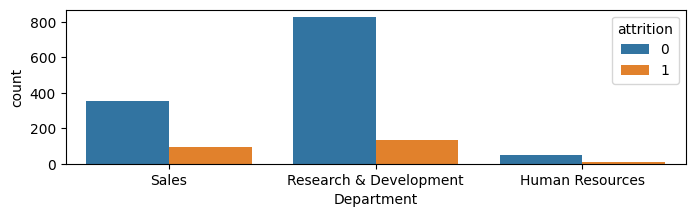

In [746]:
plt.figure(figsize=(8,2))
sns.countplot(data,x='Department',hue='attrition')
plt.show()

In [747]:
# use map
data.loc[:,'Department']=data.loc[:,'Department'].map({'Research & Development':2,'Sales':1,'Human Resources':0})

In [748]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,overtime,Gender_Female,Gender_Male
0,41,Yes,2,1102,1,1,2,5,2,94,...,0,1,6,4,0,5,1,1,1,0
1,49,No,1,279,2,8,1,5,3,61,...,3,3,10,7,1,7,0,0,0,1
2,37,Yes,2,1373,2,2,2,1,4,92,...,3,3,0,0,0,0,1,1,0,1
3,33,No,1,1392,2,3,4,5,4,56,...,3,3,8,7,3,0,0,1,1,0
4,27,No,2,591,2,2,1,4,1,40,...,3,3,2,2,2,2,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,1,884,2,23,2,4,3,41,...,3,3,5,2,0,3,0,0,0,1
1466,39,No,2,613,2,6,1,4,4,42,...,5,3,7,7,1,7,0,0,0,1
1467,27,No,2,155,2,4,3,5,2,87,...,0,3,6,2,0,3,0,1,0,1
1468,49,No,1,1023,1,2,3,4,4,63,...,3,2,9,6,0,8,0,0,0,1


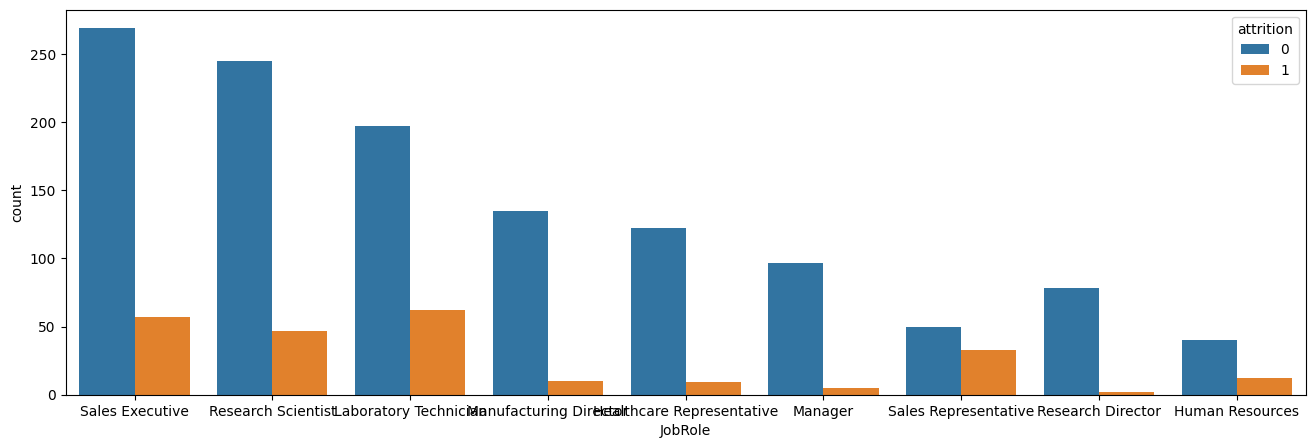

In [749]:
plt.figure(figsize=(16,5))
sns.countplot(data,x='JobRole',hue='attrition')
plt.show()

In [750]:
# use map
data.loc[:,'JobRole']=data.loc[:,'JobRole'].map({'Laboratory Technician':8,'Sales Executive':7,'Research Scientist':6,'Sales Representative':5,'Human Resources':4,'Manufacturing Director':3,'Healthcare Representative':2,'Manager':1,'Research Director':0})

In [751]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,overtime,Gender_Female,Gender_Male
0,41,Yes,2,1102,1,1,2,5,2,94,...,0,1,6,4,0,5,1,1,1,0
1,49,No,1,279,2,8,1,5,3,61,...,3,3,10,7,1,7,0,0,0,1
2,37,Yes,2,1373,2,2,2,1,4,92,...,3,3,0,0,0,0,1,1,0,1
3,33,No,1,1392,2,3,4,5,4,56,...,3,3,8,7,3,0,0,1,1,0
4,27,No,2,591,2,2,1,4,1,40,...,3,3,2,2,2,2,0,0,0,1


In [752]:
data.drop(columns=['Attrition'],inplace=True)
data.drop(columns=['OverTime'],inplace=True)

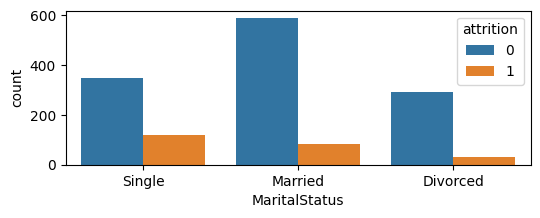

In [753]:
plt.figure(figsize=(6,2))
sns.countplot(data,x='MaritalStatus',hue='attrition')
plt.show()

In [754]:
# use map
data.loc[:,'MaritalStatus']=data.loc[:,'MaritalStatus'].map({'Single':2,'Married':1,'Divorced':0})

# **Scaling**

In [755]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Age']]=scaler.fit_transform(data[['Age']])
data[['DistanceFromHome']]=scaler.fit_transform(data[['DistanceFromHome']])
data[['MonthlyIncome']]=scaler.fit_transform(data[['MonthlyIncome']])
data[['YearsAtCompany']]=scaler.fit_transform(data[['YearsAtCompany']])

In [756]:
data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,overtime,Gender_Female,Gender_Male
0,0.446350,2,1102,1,-1.010909,2,5,2,94,3,...,0,1,-0.164613,4,0,5,1,1,1,0
1,1.322365,1,279,2,-0.147150,1,5,3,61,2,...,3,3,0.488508,7,1,7,0,0,0,1
2,0.008343,2,1373,2,-0.887515,2,1,4,92,2,...,3,3,-1.144294,0,0,0,1,1,0,1
3,-0.429664,1,1392,2,-0.764121,4,5,4,56,3,...,3,3,0.161947,7,3,0,0,1,1,0
4,-1.086676,2,591,2,-0.887515,1,4,1,40,3,...,3,3,-0.817734,2,2,2,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,1,884,2,1.703764,2,4,3,41,4,...,3,3,-0.327893,2,0,3,0,0,0,1
1466,0.227347,2,613,2,-0.393938,1,4,4,42,2,...,5,3,-0.001333,7,1,7,0,0,0,1
1467,-1.086676,2,155,2,-0.640727,3,5,2,87,4,...,0,3,-0.164613,2,0,3,0,1,0,1
1468,1.322365,1,1023,1,-0.887515,3,4,4,63,2,...,3,2,0.325228,6,0,8,0,0,0,1


In [757]:
data.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'attrition',
       'overtime', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [758]:
print(data.dtypes)

Age                         float64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome            float64
Education                     int64
EducationField               object
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany              float64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager        

In [759]:
data['overtime'] = data['overtime'].astype(int)
data['attrition'] = data['attrition'].astype(int)
data['BusinessTravel'] = data['BusinessTravel'].astype(int)
data['MaritalStatus']=data['MaritalStatus'].astype(int)

In [760]:
data['MaritalStatus']=data['MaritalStatus'].astype(int)
data['JobRole']=data['JobRole'].astype(int)
data['EducationField']=data['EducationField'].astype(int)
data['Department']=data['Department'].astype(int)

# Split data for x and y

In [761]:
x = data.drop(columns='attrition')
y= data['attrition']

# Split data for training and testing

In [762]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Balancing data

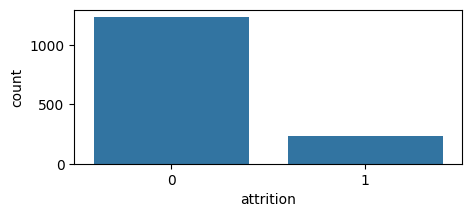

In [763]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='attrition')
plt.show()

In [764]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)
# Balancing should be done only on training data

In [765]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=6000)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [766]:
model.intercept_

array([4.87308483])

In [767]:
model.predict_proba(x_test)

array([[7.71563032e-01, 2.28436968e-01],
       [9.95134324e-01, 4.86567603e-03],
       [9.54067686e-02, 9.04593231e-01],
       [9.61700885e-01, 3.82991153e-02],
       [9.63823141e-01, 3.61768595e-02],
       [9.54508035e-01, 4.54919648e-02],
       [3.19962586e-01, 6.80037414e-01],
       [9.53161823e-01, 4.68381771e-02],
       [5.00446226e-01, 4.99553774e-01],
       [9.83007671e-01, 1.69923290e-02],
       [7.53002628e-01, 2.46997372e-01],
       [8.17877149e-01, 1.82122851e-01],
       [8.47687163e-01, 1.52312837e-01],
       [9.59391244e-01, 4.06087556e-02],
       [8.48532459e-01, 1.51467541e-01],
       [8.87741871e-01, 1.12258129e-01],
       [8.49555922e-01, 1.50444078e-01],
       [9.20249819e-01, 7.97501810e-02],
       [7.21685529e-01, 2.78314471e-01],
       [9.79670681e-01, 2.03293186e-02],
       [2.56750240e-01, 7.43249760e-01],
       [9.95960821e-01, 4.03917942e-03],
       [5.82300207e-01, 4.17699793e-01],
       [2.21136212e-01, 7.78863788e-01],
       [6.326744

# **Evaluate the model**

In [768]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [769]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[223  32]
 [ 19  20]]
Accuracy:  0.826530612244898
Recall:  0.5128205128205128
Precision:  0.38461538461538464
f1_score:  0.43956043956043955


## **AUC ROC curve**

In [770]:
from sklearn.metrics import roc_curve,roc_auc_score

In [771]:
# prob
y_prob=model.predict_proba(x_test)[:,1]
y_prob

array([2.28436968e-01, 4.86567603e-03, 9.04593231e-01, 3.82991153e-02,
       3.61768595e-02, 4.54919648e-02, 6.80037414e-01, 4.68381771e-02,
       4.99553774e-01, 1.69923290e-02, 2.46997372e-01, 1.82122851e-01,
       1.52312837e-01, 4.06087556e-02, 1.51467541e-01, 1.12258129e-01,
       1.50444078e-01, 7.97501810e-02, 2.78314471e-01, 2.03293186e-02,
       7.43249760e-01, 4.03917942e-03, 4.17699793e-01, 7.78863788e-01,
       3.67325571e-01, 2.82493999e-01, 7.71878914e-02, 8.86684861e-02,
       3.99425745e-01, 8.14717124e-02, 1.40226881e-02, 3.87687995e-03,
       1.69630808e-03, 4.05120025e-03, 7.27318735e-01, 8.59271302e-03,
       1.21291441e-02, 8.02619318e-01, 7.28223142e-01, 1.14934694e-01,
       4.90707774e-01, 5.92855770e-01, 1.45382951e-01, 8.30389807e-02,
       4.96264290e-01, 8.78266623e-02, 8.59666615e-01, 7.35048954e-01,
       6.30291399e-01, 8.56256590e-01, 2.87221702e-02, 2.98226960e-01,
       1.64460344e-03, 2.80463008e-01, 2.08210153e-01, 1.56616923e-02,
      

In [772]:
roc_auc_score(y_test,y_prob)

np.float64(0.7596782302664656)

In [773]:
# fpr v/s tpr
fpr,tpr,threshold = roc_curve(y_test,y_prob)

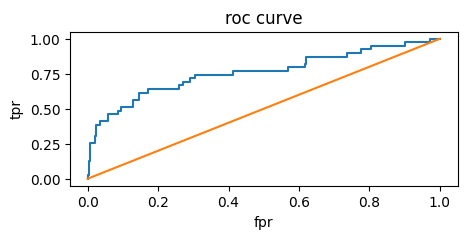

In [774]:
# plot roc curve
plt.figure(figsize=(5,2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('roc curve')
plt.show()

# **KNN Classifier**

In [775]:
from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors=7)
model1.fit(x_sampled,y_sampled)
y_pred1 = model.predict(x_test)

In [776]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred1))
print("Accuracy: " ,accuracy_score(y_test,y_pred1))
print('Recall: ',recall_score(y_test,y_pred1))
print('Precision: ',precision_score(y_test,y_pred1))
print('f1_score: ',f1_score(y_test,y_pred1))

confusion matrix
 [[223  32]
 [ 19  20]]
Accuracy:  0.826530612244898
Recall:  0.5128205128205128
Precision:  0.38461538461538464
f1_score:  0.43956043956043955


# **Decision Tree Classifier**

In [777]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(x_sampled,y_sampled)
y_pred2 = model.predict(x_test)

In [778]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred2))
print("Accuracy: " ,accuracy_score(y_test,y_pred2))
print('Recall: ',recall_score(y_test,y_pred2))
print('Precision: ',precision_score(y_test,y_pred2))
print('f1_score: ',f1_score(y_test,y_pred2))

confusion matrix
 [[223  32]
 [ 19  20]]
Accuracy:  0.826530612244898
Recall:  0.5128205128205128
Precision:  0.38461538461538464
f1_score:  0.43956043956043955


In [779]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',max_depth=50,max_features='sqrt',splitter='best',min_samples_leaf=5,min_samples_split=6,random_state=42)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [780]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[213  42]
 [ 28  11]]
Accuracy:  0.7619047619047619
Recall:  0.28205128205128205
Precision:  0.20754716981132076
f1_score:  0.2391304347826087


# **Random Forest Classifier**

In [781]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier()
model3.fit(x_sampled,y_sampled)
y_pred3 = model.predict(x_test)

In [782]:
# evaluate
print("confusion matrix\n", confusion_matrix(y_test,y_pred3))
print("Accuracy: " ,accuracy_score(y_test,y_pred3))
print('Recall: ',recall_score(y_test,y_pred3))
print('Precision: ',precision_score(y_test,y_pred3))
print('f1_score: ',f1_score(y_test,y_pred3))

confusion matrix
 [[213  42]
 [ 28  11]]
Accuracy:  0.7619047619047619
Recall:  0.28205128205128205
Precision:  0.20754716981132076
f1_score:  0.2391304347826087


In [783]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,max_depth=50,
                               bootstrap=True,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [784]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[238  17]
 [ 25  14]]
Accuracy:  0.8571428571428571
Recall:  0.358974358974359
Precision:  0.45161290322580644
f1_score:  0.4


# **Gradient Boosting**

In [785]:
from sklearn.ensemble import GradientBoostingClassifier
model4 = GradientBoostingClassifier()
model4.fit(x_sampled,y_sampled)
y_pred4 = model.predict(x_test)

In [786]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred4))
print("Accuracy: " ,accuracy_score(y_test,y_pred4))
print('Recall: ',recall_score(y_test,y_pred4))
print('Precision: ',precision_score(y_test,y_pred4))
print('f1_score: ',f1_score(y_test,y_pred4))

confusion matrix
 [[238  17]
 [ 25  14]]
Accuracy:  0.8571428571428571
Recall:  0.358974358974359
Precision:  0.45161290322580644
f1_score:  0.4


In [787]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=10,max_depth=50,
                               learning_rate=0.01,
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [788]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[235  20]
 [ 27  12]]
Accuracy:  0.8401360544217688
Recall:  0.3076923076923077
Precision:  0.375
f1_score:  0.3380281690140845


# **XGBOOST Classifier**

In [789]:
from xgboost import XGBClassifier
model5 = XGBClassifier()
model5.fit(x_sampled,y_sampled)
y_pred5 = model.predict(x_test)

In [790]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred5))
print("Accuracy: " ,accuracy_score(y_test,y_pred5))
print('Recall: ',recall_score(y_test,y_pred5))
print('Precision: ',precision_score(y_test,y_pred5))
print('f1_score: ',f1_score(y_test,y_pred5))

confusion matrix
 [[235  20]
 [ 27  12]]
Accuracy:  0.8401360544217688
Recall:  0.3076923076923077
Precision:  0.375
f1_score:  0.3380281690140845


In [791]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [792]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[241  14]
 [ 27  12]]
Accuracy:  0.8605442176870748
Recall:  0.3076923076923077
Precision:  0.46153846153846156
f1_score:  0.36923076923076925


# **K Fold Cross validation**

In [793]:
from sklearn.model_selection import KFold , cross_val_score
model = XGBClassifier()
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_sampled,y_sampled,cv=kf)
print(scores)
print(np.mean(scores))

[0.90816327 0.91560102 0.90792839 0.93861893 0.9028133 ]
0.9146249804269534


# **Stratified Cross validation**

In [794]:
from sklearn.model_selection import StratifiedKFold
model = XGBClassifier()
sf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_sampled,y_sampled,cv=sf)
print(scores)
print(np.mean(scores))

[0.91836735 0.92071611 0.90792839 0.91560102 0.9258312 ]
0.9176888146562974


# **Comparison Table of metrics**

In [795]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Re-train models to ensure they are fitted and to correct prediction assignments
# Logistic Regression
model_lr = LogisticRegression(max_iter=60000) # Increased max_iter further to address convergence warning
model_lr.fit(x_sampled, y_sampled)
y_pred_lr = model_lr.predict(x_test)

# KNN Classifier
model1 = KNeighborsClassifier(n_neighbors=7)
model1.fit(x_sampled, y_sampled)
y_pred1 = model1.predict(x_test)

# Decision Tree Classifier
model2 = DecisionTreeClassifier()
model2.fit(x_sampled, y_sampled)
y_pred2 = model2.predict(x_test)

# Random Forest Classifier (using the hyper-parameters from the last execution in the notebook)
model3 = RandomForestClassifier(n_estimators=10,max_depth=50,
                               bootstrap=True,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
model3.fit(x_sampled, y_sampled)
y_pred3 = model3.predict(x_test)

# Gradient Boosting Classifier (using the hyper-parameters from the last execution in the notebook)
model4 = GradientBoostingClassifier()
model4.fit(x_sampled, y_sampled)
y_pred4 = model4.predict(x_test)

# XGBoost Classifier (using the hyper-parameters from the last execution in the notebook)
model5 = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model5.fit(x_sampled, y_sampled)
y_pred5 = model5.predict(x_test)


# List to store metrics
comparison_list = []

# Now, `my_models` will correctly refer to the fitted models and their predictions
my_models = [
    ("Logistic Regression", model_lr, y_pred_lr),
    ("KNN", model1, y_pred1),
    ("Decision Tree", model2, y_pred2),
    ("Random Forest", model3, y_pred3),
    ("Gradient Boosting", model4, y_pred4),
    ("XG Boosting", model5, y_pred5)
]

for name, m, p in my_models:
    if hasattr(m, 'predict_proba'):
        y_prob = m.predict_proba(x_test)[:, 1]
    else:
        y_prob = None

    comparison_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p),
        "Recall": recall_score(y_test, p),
        "F1 Score": f1_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')
    })

comparison_df = pd.DataFrame(comparison_list)

comparison_df.set_index("Model", inplace=True)
# Display the horizontal table
display(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.853741,0.456522,0.538462,0.494118,0.772348
KNN,0.588435,0.146552,0.435897,0.219355,0.556461
Decision Tree,0.727891,0.211268,0.384615,0.272727,0.582504
Random Forest,0.863946,0.482759,0.358974,0.411765,0.772298
Gradient Boosting,0.863946,0.487179,0.487179,0.487179,0.772750
XG Boosting,0.860544,0.461538,0.307692,0.369231,0.759175


# **Based on the comparison table:**

**Logistic Regression**: This model performs very well, achieving the highest ROC-AUC (0.772), Recall (0.538), and F1 Score (0.494). It also has a strong Accuracy (0.854).

**Gradient Boosting**: This model has the highest Accuracy (0.864) and a good F1 Score (0.487).

**XGBoost**: It also shows good performance with high Accuracy (0.861) and a competitive ROC-AUC (0.762).

**F1 Score and ROC-AUC which are often crucial for imbalanced datasets like attrition prediction, Logistic Regression appears to be the most robust and overall best-performing model among those evaluated.**

# **Final Insight**
**Key Influencing the attrition**

--- Top 10 Attrition Factors ---
StockOptionLevel    0.212800
JobLevel            0.122041
Department          0.098436
Gender_Male         0.043142
JobInvolvement      0.039995
Gender_Female       0.039697
JobSatisfaction     0.036736
BusinessTravel      0.027683
WorkLifeBalance     0.026753
overtime            0.025465
dtype: float32


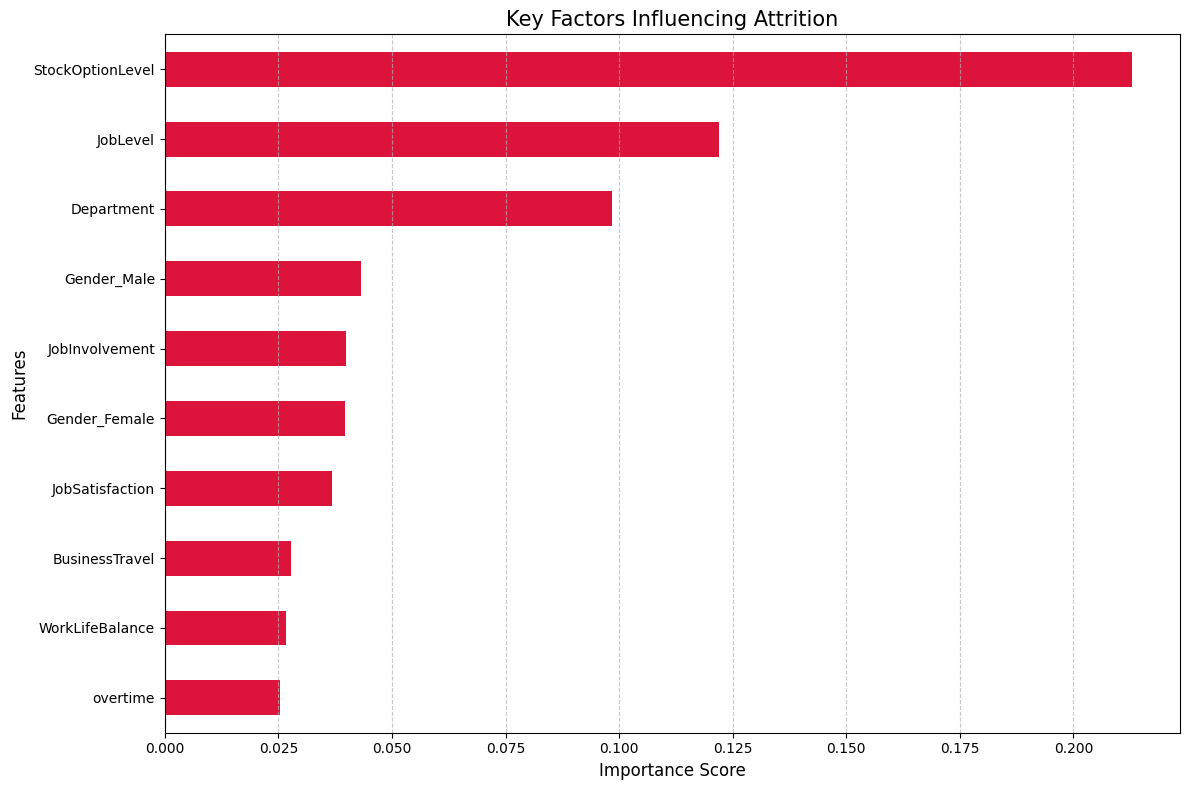

In [796]:
import matplotlib.pyplot as plt
import pandas as pd
importances = pd.Series(model5.feature_importances_, index=x_sampled.columns)
top_10 = importances.nlargest(10)
print("--- Top 10 Attrition Factors ---")
print(top_10)
plt.figure(figsize=(12, 8))
top_10.plot(kind='barh', color='crimson')
plt.title('Key Factors Influencing Attrition', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Therefore, key factors influencing attrition is stockoption level**

# **Business recommendation**
**Optimize Compensation & Benefits:** Regularly review and benchmark stock option plans and job level compensation to ensure competitiveness and reward long-term commitment.

**Enhance Employee Experience:** Implement programs to boost job involvement and satisfaction, address work-life balance and overtime, and conduct targeted interventions for specific departments and gender dynamics.